In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
from PIL import Image
from unet import UNet
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch

from tqdm import tqdm
import torch
from insect_dataset import InsectKPDataset

from cpm_model_v2 import CPM

c:\Users\nangb\miniconda3\envs\insect_model\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\nangb\miniconda3\envs\insect_model\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
def heatmap2coord(heatmap, topk=5):
    N, C, H, W = heatmap.shape
    score, index = heatmap.view(N,C,1,-1).topk(topk, dim=-1)
    coord = torch.cat([index%W, index//W], dim=2)
    coord = (coord*torch.nn.functional.softmax(score, dim=-1)).sum(-1) * 8
    return coord
    
def draw_lmk(heatmap, lmk=None, img=None):
    if lmk is None:
        lmk = heatmap2coord(heatmap[:, 1:, ], topk = 5).numpy()[0]
    
    if img is None:
        tmp = np.zeros((224, 224, 3), dtype=np.uint8)
    else:
        tmp = img
    for i, xy in enumerate(lmk):
        x, y = int(xy[0]), int(xy[1])
        cv2.circle(tmp, (x, y), 3, (255, 0, 0), -1)
        tmp = cv2.putText(tmp, f"{i}", (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1, cv2.LINE_AA)

    return tmp

In [3]:
# model = UNet(n_channels = 3, n_classes = 8)
# model = model.cuda()
# model = model.eval()

# model = CPM(n_keypoints = 5, channels = 3)
model = CPM(5)
model = model.cuda()
model = model.eval()

In [4]:
#checkpoint_path = "ckpt/KP-Prediction-Heatmap-5+1Points-CPM-V2-FrontalProfile-LR-Aug-Scheduler-MSE/epoch-latest.pth"
checkpoint_path = "epoch-latest.pth"
checkpoint = torch.load(checkpoint_path, map_location="cpu")["state_dict"]
state_dict = {}
for key in checkpoint:
    state_dict[key.replace("module.", "")] = checkpoint[key]

msg = model.load_state_dict(state_dict)

model.eval()
print(msg)

<All keys matched successfully>


Dataset (test) has 156 samples


C:\Users\nangb\AppData\Local\Temp\ipykernel_14768\2163545870.py:4: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  coord = torch.cat([index%W, index//W], dim=2)


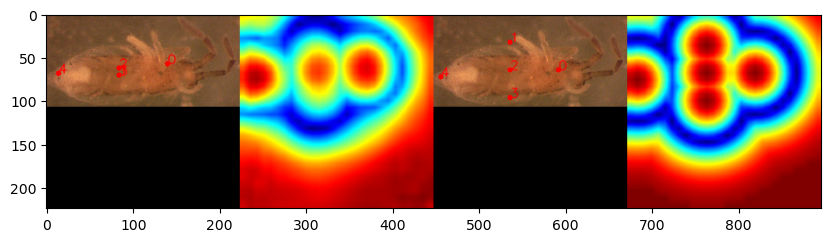

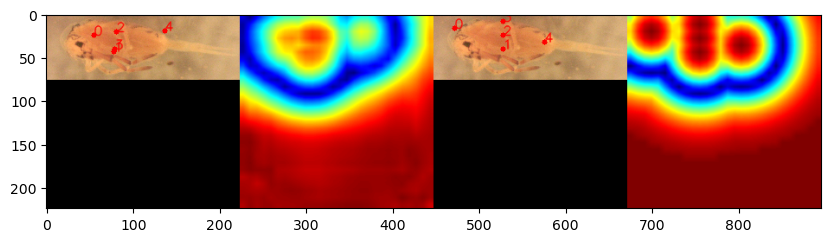

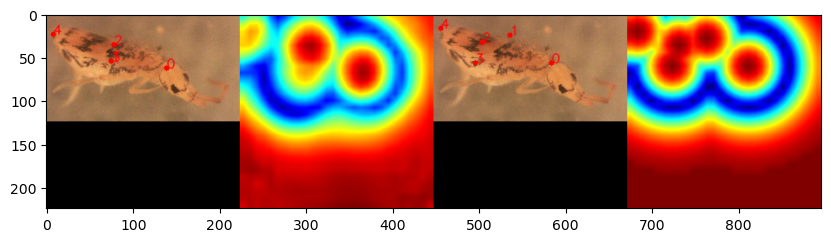

In [5]:
output_dir = "output_lmks_full"
os.makedirs(output_dir, exist_ok=True) 
split = "test"
dataset = InsectKPDataset("data", split)
# for i in [0, 10, 20, 50, 100]: 
for i in range(3):  #len(dataset)): 
    img, heatmap, centermap = dataset[i]
    # print(heatmap.max(), heatmap.min())
    heatmap = torch.from_numpy(heatmap)
    centermap = torch.from_numpy(centermap).unsqueeze(0).cuda()
    batched_img = img.unsqueeze(0).cuda()
    cv_img = img.numpy() * 255
    cv_img = cv_img.astype(np.uint8).transpose(1, 2, 0)
    
    pred = model(batched_img, centermap)
    pred = pred[-1].cpu().detach()
    heat = pred[0].numpy().max(axis=0)
    heat = (heat - heat.min()) / (heat.max() - heat.min()) * 255
    heat = heat.astype(np.uint8)
    heat = cv2.resize(heat, (224, 224))
    heat1 = cv2.applyColorMap(heat, cv2.COLORMAP_JET)[..., ::-1]
    # heat1 = cv2.resize(heat1, (224, 224))

    heat = heatmap.numpy().max(axis=0)
    heat = (heat - heat.min()) / (heat.max() - heat.min()) * 255
    heat = heat.astype(np.uint8)
    heat = cv2.resize(heat, (224, 224))
    heat2 = cv2.applyColorMap(heat, cv2.COLORMAP_JET)[..., ::-1]
    
    pred_img = draw_lmk(pred, img = cv_img.copy())
    gt_img = draw_lmk(heatmap[None], img = cv_img.copy())
    pre_lmk = np.concatenate([pred_img, heat1, gt_img, heat2], axis=1)
    if (i < 5):
        plt.figure(figsize=(10, 10))
        plt.imshow(pre_lmk)

    # cv2.imwrite(f"{output_dir}/{split}_{i:06d}.jpg", pre_lmk[:, :, ::-1])